In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
X_train = pd.read_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/X_train_scaled.csv'
)

X_test = pd.read_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/X_test_scaled.csv'
)

y_train = pd.read_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/y_train.csv'
)

y_test = pd.read_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/y_test.csv'
)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 9)
X_test shape: (2000, 9)
y_train shape: (8000, 1)
y_test shape: (2000, 1)


In [ ]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [ ]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (8000,)
y_test shape: (2000,)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

In [ ]:
logistic_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = logistic_model.predict(X_test)

In [ ]:
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba[:10])

First 10 predictions:
[1 1 1 0 1 1 1 0 0 1]

First 10 failure probabilities:
[0.94357233 0.63480466 0.71631167 0.01860562 0.8388973  0.59844746
 0.77151634 0.16962623 0.02497291 0.53613784]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 0.8345
Precision: 0.1549
Recall   : 0.8676
F1 Score : 0.2628
ROC-AUC  : 0.9139


Confusion Matrix:
[[1610  322]
 [   9   59]]


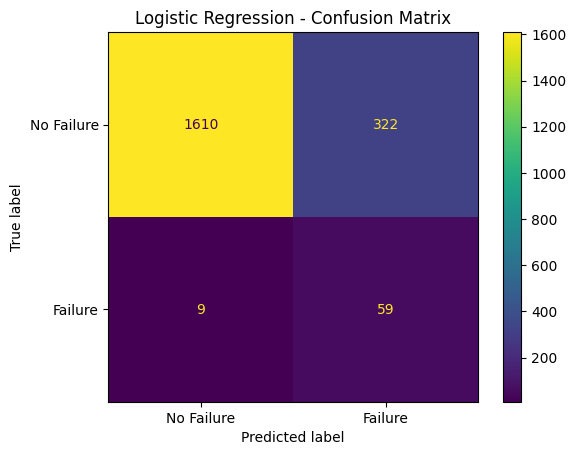

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring
)

In [ ]:
print("Logistic Regression - 5-Fold Cross Validation")
print("---------------------------------------------")

print(f"Mean Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f}")

Logistic Regression - 5-Fold Cross Validation
---------------------------------------------
Mean Accuracy : 0.8274
Mean Precision: 0.1429
Mean Recall   : 0.8193
Mean F1 Score : 0.2433
Mean ROC-AUC  : 0.9024


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba_rf[:10])

First 10 Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 failure probabilities:
[0.225 0.    0.075 0.    0.01  0.    0.005 0.    0.    0.02 ]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.9880
Precision: 0.9583
Recall   : 0.6765
F1 Score : 0.7931
ROC-AUC  : 0.9705


Random Forest Confusion Matrix:
[[1930    2]
 [  22   46]]


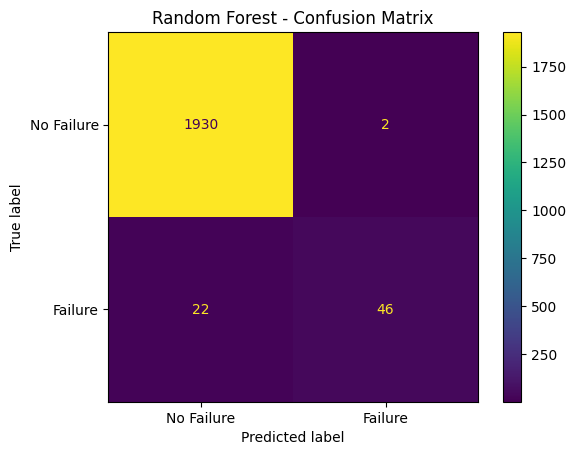

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results_rf = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("Random Forest - 5-Fold Cross Validation")
print("---------------------------------------")

print(f"Mean Accuracy : {cv_results_rf['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_rf['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results_rf['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_rf['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_rf['test_roc_auc'].mean():.4f}")

Random Forest - 5-Fold Cross Validation
---------------------------------------
Mean Accuracy : 0.9832
Mean Precision: 0.9247
Mean Recall   : 0.5500
Mean F1 Score : 0.6894
Mean ROC-AUC  : 0.9692


In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

In [ ]:
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]

In [ ]:
print("First 10 SVM predictions:")
print(y_pred_svm[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba_svm[:10])

First 10 SVM predictions:
[1 0 1 0 0 1 1 0 0 0]

First 10 failure probabilities:
[3.10069153e-01 1.18329435e-03 6.64117348e-02 2.76530588e-03
 4.30000971e-02 1.09626601e-01 1.88381733e-01 1.03575591e-03
 2.65843903e-04 2.62651973e-02]


In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

print("SVM Performance")
print("----------------")
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_auc_svm:.4f}")

SVM Performance
----------------
Accuracy : 0.9135
Precision: 0.2727
Recall   : 0.9265
F1 Score : 0.4214
ROC-AUC  : 0.9680


SVM Confusion Matrix:
[[1764  168]
 [   5   63]]


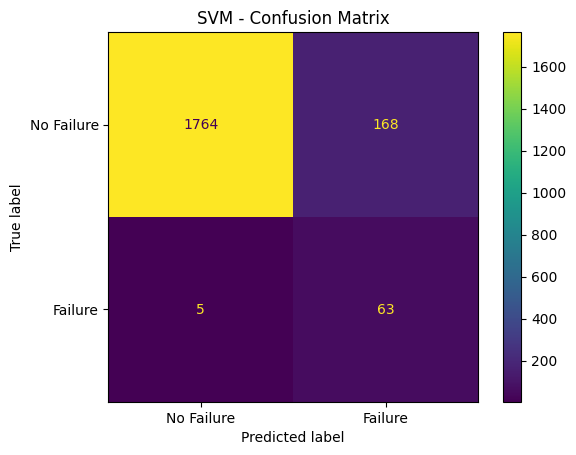

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("SVM - Confusion Matrix")
plt.show()

In [ ]:
cv_results_svm = cross_validate(
    svm_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("SVM - 5-Fold Cross Validation")
print("----------------------------")

print(f"Mean Accuracy : {cv_results_svm['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_svm['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results_svm['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_svm['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_svm['test_roc_auc'].mean():.4f}")

SVM - 5-Fold Cross Validation
----------------------------
Mean Accuracy : 0.9197
Mean Precision: 0.2777
Mean Recall   : 0.8524
Mean F1 Score : 0.4187
Mean ROC-AUC  : 0.9565


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

In [ ]:
print("First 10 Decision Tree predictions:")
print(y_pred_dt[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba_dt[:10])

First 10 Decision Tree predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 failure probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Decision Tree Performance
-------------------------
Accuracy : 0.9770
Precision: 0.6719
Recall   : 0.6324
F1 Score : 0.6515
ROC-AUC  : 0.8107


Decision Tree Confusion Matrix:
[[1911   21]
 [  25   43]]


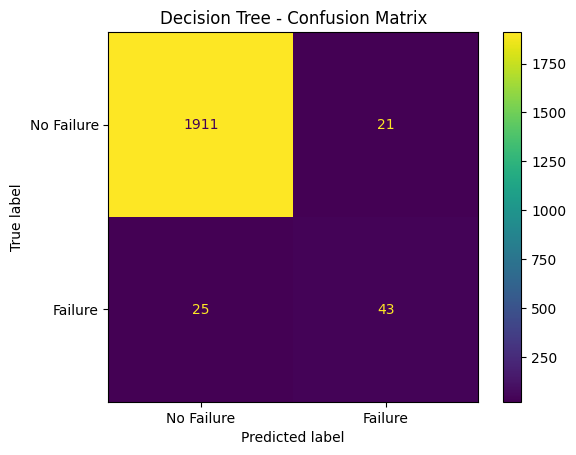

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [ ]:
cv_results_dt = cross_validate(
    dt_model,
    X_train,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("Decision Tree - 5-Fold Cross Validation")
print("---------------------------------------")

print(f"Mean Accuracy : {cv_results_dt['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_dt['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results_dt['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_dt['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_dt['test_roc_auc'].mean():.4f}")

Decision Tree - 5-Fold Cross Validation
---------------------------------------
Mean Accuracy : 0.9776
Mean Precision: 0.6902
Mean Recall   : 0.6202
Mean F1 Score : 0.6524
Mean ROC-AUC  : 0.8052


In [ ]:
class_counts = y_train.value_counts()

scale_pos_weight = class_counts[0] / class_counts[1]

print("Class 0 count:", class_counts[0])
print("Class 1 count:", class_counts[1])
print("Scale Pos Weight:", scale_pos_weight)

Class 0 count: 7729
Class 1 count: 271
Scale Pos Weight: 28.52029520295203


In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = [
    'Air_temperature',
    'Process_temperature',
    'Rotational_speed',
    'Torque',
    'Tool_wear',
    'Type_L',
    'Type_M',
    'Temperature_difference',
    'Tool_wear_level'
]

X_test_xgb.columns = X_train_xgb.columns

In [ ]:
xgb_model.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
print("First 10 XGBoost predictions:")
print(y_pred_xgb[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba_xgb[:10])

First 10 XGBoost predictions:
[0 0 1 0 0 0 0 0 0 0]

First 10 failure probabilities:
[3.2627261e-01 1.1251433e-03 5.4384857e-01 2.0186363e-03 4.2622346e-02
 6.7657288e-03 4.3402173e-02 9.4071487e-03 3.9958910e-04 4.7945872e-02]


In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("XGBoost Performance")
print("-------------------")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

XGBoost Performance
-------------------
Accuracy : 0.9710
Precision: 0.5481
Recall   : 0.8382
F1 Score : 0.6628
ROC-AUC  : 0.9758


XGBoost Confusion Matrix:
[[1885   47]
 [  11   57]]


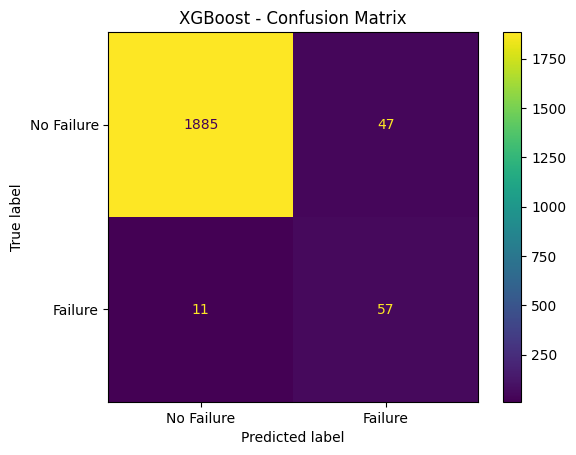

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [ ]:
cv_results_xgb = cross_validate(
    xgb_model,
    X_train_xgb,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("XGBoost - 5-Fold Cross Validation")
print("--------------------------------")

print(f"Mean Accuracy : {cv_results_xgb['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_xgb['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results_xgb['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_xgb['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_xgb['test_roc_auc'].mean():.4f}")

XGBoost - 5-Fold Cross Validation
--------------------------------
Mean Accuracy : 0.9765
Mean Precision: 0.6175
Mean Recall   : 0.8154
Mean F1 Score : 0.7016
Mean ROC-AUC  : 0.9750


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'XGBoost'
    ],

    'Test Accuracy': [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm,
        accuracy_xgb
    ],

    'Test Precision': [
        precision,
        precision_dt,
        precision_rf,
        precision_svm,
        precision_xgb
    ],

    'Test Recall': [
        recall,
        recall_dt,
        recall_rf,
        recall_svm,
        recall_xgb
    ],

    'Test F1 Score': [
        f1,
        f1_dt,
        f1_rf,
        f1_svm,
        f1_xgb
    ],

    'Test ROC-AUC': [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_svm,
        roc_auc_xgb
    ],

    'CV Accuracy': [
        cv_results['test_accuracy'].mean(),
        cv_results_dt['test_accuracy'].mean(),
        cv_results_rf['test_accuracy'].mean(),
        cv_results_svm['test_accuracy'].mean(),
        cv_results_xgb['test_accuracy'].mean()
    ],

    'CV Precision': [
        cv_results['test_precision'].mean(),
        cv_results_dt['test_precision'].mean(),
        cv_results_rf['test_precision'].mean(),
        cv_results_svm['test_precision'].mean(),
        cv_results_xgb['test_precision'].mean()
    ],

    'CV Recall': [
        cv_results['test_recall'].mean(),
        cv_results_dt['test_recall'].mean(),
        cv_results_rf['test_recall'].mean(),
        cv_results_svm['test_recall'].mean(),
        cv_results_xgb['test_recall'].mean()
    ],

    'CV F1 Score': [
        cv_results['test_f1'].mean(),
        cv_results_dt['test_f1'].mean(),
        cv_results_rf['test_f1'].mean(),
        cv_results_svm['test_f1'].mean(),
        cv_results_xgb['test_f1'].mean()
    ],

    'CV ROC-AUC': [
        cv_results['test_roc_auc'].mean(),
        cv_results_dt['test_roc_auc'].mean(),
        cv_results_rf['test_roc_auc'].mean(),
        cv_results_svm['test_roc_auc'].mean(),
        cv_results_xgb['test_roc_auc'].mean()
    ]
})



In [ ]:
comparison.round(4)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Test ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC-AUC
0,Logistic Regression,0.8345,0.1549,0.8676,0.2628,0.9139,0.8274,0.1429,0.8193,0.2433,0.9024
1,Decision Tree,0.9770,0.6719,0.6324,0.6515,0.8107,0.9776,0.6902,0.6202,0.6524,0.8052
2,Random Forest,0.9880,0.9583,0.6765,0.7931,0.9705,0.9832,0.9247,0.5500,0.6894,0.9692
3,SVM,0.9135,0.2727,0.9265,0.4214,0.9680,0.9198,0.2777,0.8524,0.4187,0.9565
4,XGBoost,0.9710,0.5481,0.8382,0.6628,0.9758,0.9765,0.6175,0.8154,0.7016,0.9750


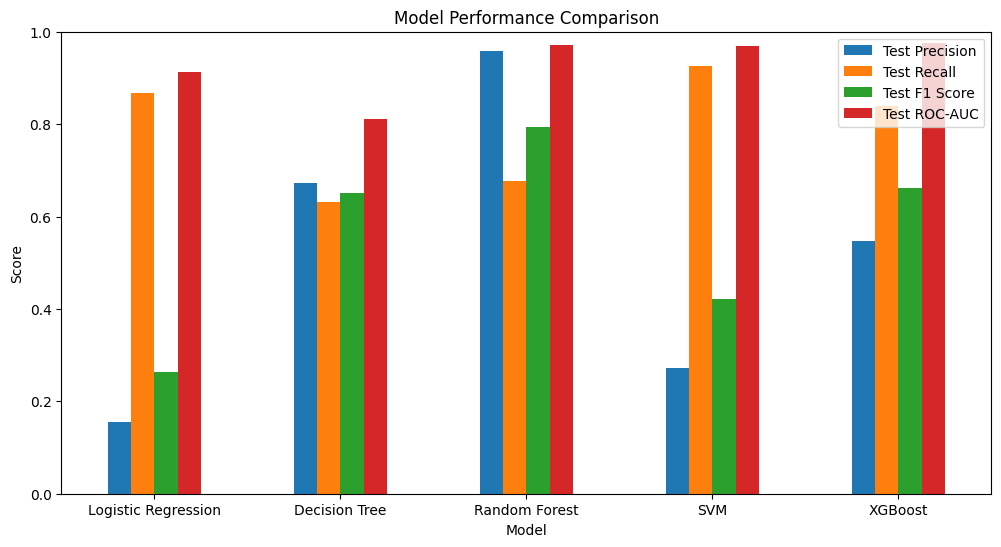

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Test Precision', 'Test Recall', 'Test F1 Score', 'Test ROC-AUC']

comparison_plot = comparison.set_index('Model')[metrics]

comparison_plot.plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from scipy.stats import randint, uniform

In [ ]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.19),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(1, 8)
}

In [ ]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
xgb_random_search.fit(X_train_xgb, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca9720a8b90>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca9709aca50>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ca9709e92b0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ca9720a87d0>},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV F1 Score:")
print(xgb_random_search.best_score_)

Best Parameters:
{'colsample_bytree': np.float64(0.8166031869068445), 'learning_rate': np.float64(0.061556316037040225), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 316, 'subsample': np.float64(0.7842803529062142)}

Best CV F1 Score:
0.774762591360943


In [ ]:
best_xgb_model = xgb_random_search.best_estimator_

In [ ]:
print(best_xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8166031869068445), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.061556316037040225), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=316, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
y_pred_tuned_xgb = best_xgb_model.predict(X_test_xgb)
y_pred_proba_tuned_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

In [ ]:
print("First 10 tuned XGBoost predictions:")
print(y_pred_tuned_xgb[:10])

print("\nFirst 10 failure probabilities:")
print(y_pred_proba_tuned_xgb[:10])

First 10 tuned XGBoost predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 failure probabilities:
[2.2377737e-01 6.9043439e-05 4.6491366e-02 1.0418316e-03 1.4307190e-02
 9.3952804e-05 7.1848296e-03 2.1549279e-04 3.8495185e-05 1.5907660e-02]


In [ ]:
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb)
recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb)
f1_tuned_xgb = f1_score(y_test, y_pred_tuned_xgb)
roc_auc_tuned_xgb = roc_auc_score(y_test, y_pred_proba_tuned_xgb)

print("Tuned XGBoost Performance")
print("-------------------------")
print(f"Accuracy : {accuracy_tuned_xgb:.4f}")
print(f"Precision: {precision_tuned_xgb:.4f}")
print(f"Recall   : {recall_tuned_xgb:.4f}")
print(f"F1 Score : {f1_tuned_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_tuned_xgb:.4f}")

Tuned XGBoost Performance
-------------------------
Accuracy : 0.9870
Precision: 0.8000
Recall   : 0.8235
F1 Score : 0.8116
ROC-AUC  : 0.9717


Tuned XGBoost Confusion Matrix:
[[1918   14]
 [  12   56]]


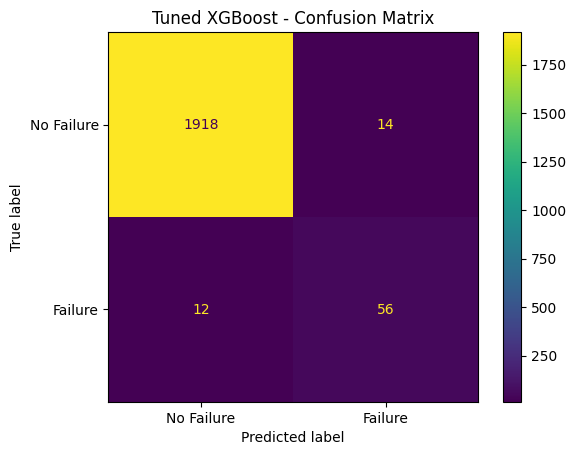

In [ ]:
cm_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)

print("Tuned XGBoost Confusion Matrix:")
print(cm_tuned_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_xgb,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

In [ ]:
cv_results_tuned_xgb = cross_validate(
    best_xgb_model,
    X_train_xgb,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

In [ ]:
print("Tuned XGBoost - 5-Fold Cross Validation")
print("---------------------------------------")

print(f"Mean Accuracy : {cv_results_tuned_xgb['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_tuned_xgb['test_precision'].mean():.4f}")
print(f"Mean Recall   : {cv_results_tuned_xgb['test_recall'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_tuned_xgb['test_f1'].mean():.4f}")
print(f"Mean ROC-AUC  : {cv_results_tuned_xgb['test_roc_auc'].mean():.4f}")

Tuned XGBoost - 5-Fold Cross Validation
---------------------------------------
Mean Accuracy : 0.9846
Mean Precision: 0.7693
Mean Recall   : 0.7824
Mean F1 Score : 0.7748
Mean ROC-AUC  : 0.9723


In [ ]:
tuned_xgb_row = pd.DataFrame({
    'Model': ['XGBoost (Tuned)'],

    'Test Accuracy': [accuracy_tuned_xgb],
    'Test Precision': [precision_tuned_xgb],
    'Test Recall': [recall_tuned_xgb],
    'Test F1 Score': [f1_tuned_xgb],
    'Test ROC-AUC': [roc_auc_tuned_xgb],

    'CV Accuracy': [cv_results_tuned_xgb['test_accuracy'].mean()],
    'CV Precision': [cv_results_tuned_xgb['test_precision'].mean()],
    'CV Recall': [cv_results_tuned_xgb['test_recall'].mean()],
    'CV F1 Score': [cv_results_tuned_xgb['test_f1'].mean()],
    'CV ROC-AUC': [cv_results_tuned_xgb['test_roc_auc'].mean()]
})

final_comparison = pd.concat(
    [comparison, tuned_xgb_row],
    ignore_index=True
)

final_comparison.round(4)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Test ROC-AUC,CV Accuracy,CV Precision,CV Recall,CV F1 Score,CV ROC-AUC
0,Logistic Regression,0.8345,0.1549,0.8676,0.2628,0.9139,0.8274,0.1429,0.8193,0.2433,0.9024
1,Decision Tree,0.9770,0.6719,0.6324,0.6515,0.8107,0.9776,0.6902,0.6202,0.6524,0.8052
2,Random Forest,0.9880,0.9583,0.6765,0.7931,0.9705,0.9832,0.9247,0.5500,0.6894,0.9692
3,SVM,0.9135,0.2727,0.9265,0.4214,0.9680,0.9198,0.2777,0.8524,0.4187,0.9565
4,XGBoost,0.9710,0.5481,0.8382,0.6628,0.9758,0.9765,0.6175,0.8154,0.7016,0.9750
5,XGBoost (Tuned),0.9870,0.8000,0.8235,0.8116,0.9717,0.9846,0.7693,0.7824,0.7748,0.9723


In [ ]:
print([name for name in globals() if 'scal' in name.lower()])

['scale_pos_weight']


In [ ]:
print("X_train type:", type(X_train))
print("X_train shape:", X_train.shape)
print("\nFirst 5 rows of X_train:")
display(X_train.head())

X_train type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (8000, 9)

First 5 rows of X_train:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M,Temperature difference [K],Tool wear level
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,-1.234366,1.536207,-1.100842,-1.216138
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,-1.234366,1.536207,1.299658,0.006726
2,0.498092,1.077466,-1.007654,0.558607,0.460870,-1.234366,1.536207,0.599512,0.006726
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.810133,-0.650954,0.899575,0.006726
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,0.810133,-0.650954,1.399679,-1.216138


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

In [ ]:
print("Scaler recreated successfully.")
print("Number of features:", len(scaler.mean_))

Scaler recreated successfully.
Number of features: 9


In [ ]:
import os
import joblib

models_path = "/content/drive/MyDrive/Predictive_Maintenance/models"

os.makedirs(models_path, exist_ok=True)

# Save the final tuned XGBoost model
joblib.dump(
    best_xgb_model,
    f"{models_path}/tuned_xgboost_model.pkl"
)

# Save the scaler
joblib.dump(
    scaler,
    f"{models_path}/scaler.pkl"
)

print("Final model and scaler saved successfully.")

Final model and scaler saved successfully.


In [ ]:
import joblib

models_path = "/content/drive/MyDrive/Predictive_Maintenance/models"

loaded_model = joblib.load(
    f"{models_path}/tuned_xgboost_model.pkl"
)

loaded_scaler = joblib.load(
    f"{models_path}/scaler.pkl"
)

print("Model loaded successfully:", type(loaded_model).__name__)
print("Scaler loaded successfully:", type(loaded_scaler).__name__)

Model loaded successfully: XGBClassifier
Scaler loaded successfully: StandardScaler


In [ ]:
loaded_predictions = loaded_model.predict(X_test_xgb)

print("Predictions identical:",
      (loaded_predictions == y_pred_tuned_xgb).all())

Predictions identical: True


In [ ]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

base_path = "/content/drive/MyDrive/Predictive_Maintenance"

# Load original dataset
df = pd.read_csv(
    f"{base_path}/ai4i2020.csv"
)

# Feature engineering
df["Temperature difference [K]"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

df["Tool wear level"] = pd.qcut(
    df["Tool wear [min]"],
    q=3,
    labels=["Low", "Medium", "High"]
).map({
    "Low": 0,
    "Medium": 1,
    "High": 2
}).astype(int)

# One-hot encode machine type
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

# Final features
feature_names = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_L",
    "Type_M",
    "Temperature difference [K]",
    "Tool wear level"
]

X = df[feature_names].copy()
y = df["Machine failure"].copy()

# Convert one-hot columns to numeric
X["Type_L"] = X["Type_L"].astype(int)
X["Type_M"] = X["Type_M"].astype(int)

# Exact 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# XGBoost-safe feature names
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = [
    "Air_temperature",
    "Process_temperature",
    "Rotational_speed",
    "Torque",
    "Tool_wear",
    "Type_L",
    "Type_M",
    "Temperature_difference",
    "Tool_wear_level"
]

X_test_xgb.columns = X_train_xgb.columns

# Class imbalance ratio
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# Final tuned XGBoost model
final_xgb_model = xgb.XGBClassifier(
    n_estimators=316,
    learning_rate=0.061556316037040225,
    max_depth=7,
    min_child_weight=2,
    subsample=0.7842803529062142,
    colsample_bytree=0.8166031869068445,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train
final_xgb_model.fit(
    X_train_xgb,
    y_train
)

# Test
y_pred = final_xgb_model.predict(X_test_xgb)
y_prob = final_xgb_model.predict_proba(X_test_xgb)[:, 1]

print("FINAL XGBOOST MODEL")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

print()
print("CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print()
print("PROBABILITY CHECK")
print("-" * 40)
print(f"Minimum probability : {y_prob.min() * 100:.2f}%")
print(f"Maximum probability : {y_prob.max() * 100:.2f}%")
print(f"Median probability  : {np.median(y_prob) * 100:.2f}%")
print(f"Mean probability    : {y_prob.mean() * 100:.2f}%")
print(f"Samples >= 90%      : {(y_prob >= 0.90).sum()} / {len(y_prob)}")

# Test Flask-like input
test_input = pd.DataFrame([[
    300,
    310,
    1400,
    30,
    20,
    0,
    0,
    10,
    0
]], columns=X_train_xgb.columns)

test_prediction = final_xgb_model.predict(test_input)[0]
test_probability = final_xgb_model.predict_proba(test_input)[0][1]

print()
print("FLASK-LIKE TEST")
print("-" * 40)
print(f"Prediction          : {test_prediction}")
print(f"Failure probability : {test_probability * 100:.2f}%")

# Save fresh model
new_model_path = f"{base_path}/models/tuned_xgboost_model.pkl"

joblib.dump(
    final_xgb_model,
    new_model_path
)

print()
print("MODEL SAVED")
print(new_model_path)

FINAL XGBOOST MODEL
----------------------------------------
Accuracy  : 0.9870
Precision : 0.8000
Recall    : 0.8235
F1 Score  : 0.8116
ROC-AUC   : 0.9717

CONFUSION MATRIX
[[1918   14]
 [  12   56]]

PROBABILITY CHECK
----------------------------------------
Minimum probability : 0.00%
Maximum probability : 99.96%
Median probability  : 0.03%
Mean probability    : 3.92%
Samples >= 90%      : 52 / 2000

FLASK-LIKE TEST
----------------------------------------
Prediction          : 0
Failure probability : 0.02%

MODEL SAVED
/content/drive/MyDrive/Predictive_Maintenance/models/tuned_xgboost_model.pkl
